In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

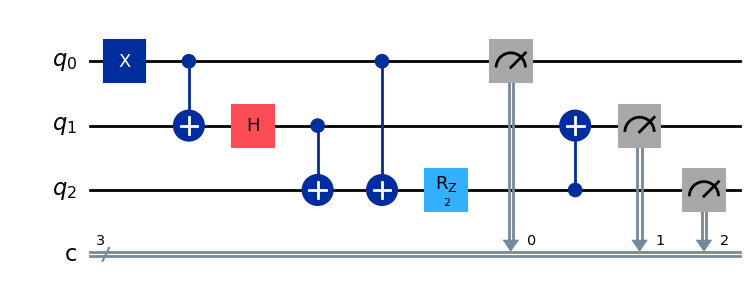

In [5]:
qc = QuantumCircuit(3, 3)
qc.x(0)
qc.cx(0, 1)
qc.h(1)
qc.cx(1, 2)
qc.cx(0, 2)
qc.rz(2, 2)
qc.cx(2, 1)
qc.measure([0, 1, 2], [0, 1, 2])
qc.draw("mpl")

In [6]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
print(backend.basis_gates)
print(backend.coupling_map) 
# transpiled_circuit.draw("mpl")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
['cz', 'id', 'rz', 'sx', 'x']
[[0, 1], [1, 0], [1, 2], [2, 1], [2, 3], [3, 2], [3, 4], [3, 16], [4, 3], [4, 5], [5, 4], [5, 6], [6, 5], [6, 7], [7, 6], [7, 8], [7, 17], [8, 7], [8, 9], [9, 8], [9, 10], [10, 9], [10, 11], [11, 10], [11, 12], [11, 18], [12, 11], [12, 13], [13, 12], [13, 14], [14, 13], [14, 15], [15, 14], [15, 19], [16, 3], [16, 23], [17, 7], [17, 27], [18, 11], [18, 31], [19, 15], [19, 35], [20, 21], [21, 20], [21, 22], [21, 36], [22, 21], [22, 23], [23, 16], [23, 22], [23, 24], [24, 23], [24, 25], [25, 24], [25, 26], [25, 37], [26, 25], [26, 27], [27, 17], [27, 26], [27, 28], [28, 27], [28, 29], [29, 28], [29, 30], [29, 38], [30, 29], [30, 31], [31, 18], [31, 30], [31, 32], [32, 31], [32, 33], [33, 32], [33, 34], [33, 39], [34, 33], [34, 35], [35, 19], [35, 34], [36, 21], [36, 41], [37, 25], [37, 45], [38, 29], [38, 49], [39, 33], [39, 53], [40, 41], [41, 3

In [9]:
sampler = Sampler(mode=backend)

experiment_accuracies = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "011" and state != "111":
            acc_sum += count
    accuracy = acc_sum / 1024
    experiment_accuracies.append(accuracy)

print("Average accuracy over 50 runs:", sum(experiment_accuracies) / len(experiment_accuracies))
print("Accuracies for each run:", experiment_accuracies)

Average accuracy over 50 runs: 0.04302734375
Accuracies for each run: [0.046875, 0.0458984375, 0.0478515625, 0.0400390625, 0.0400390625, 0.0390625, 0.04296875, 0.0478515625, 0.0400390625, 0.0439453125, 0.048828125, 0.0400390625, 0.033203125, 0.033203125, 0.0458984375, 0.0419921875, 0.044921875, 0.046875, 0.0576171875, 0.0439453125, 0.0419921875, 0.0390625, 0.0458984375, 0.0400390625, 0.0400390625, 0.03515625, 0.0498046875, 0.03515625, 0.0341796875, 0.0478515625, 0.041015625, 0.0419921875, 0.0498046875, 0.052734375, 0.0400390625, 0.0478515625, 0.052734375, 0.0380859375, 0.041015625, 0.03515625, 0.05078125, 0.0361328125, 0.0439453125, 0.0419921875, 0.041015625, 0.0517578125, 0.044921875, 0.03515625, 0.04296875, 0.0419921875]


In [2]:
import numpy as np
errors = [0.046875, 0.0458984375, 0.0478515625, 0.0400390625, 0.0400390625, 0.0390625, 0.04296875, 0.0478515625, 0.0400390625, 0.0439453125, 0.048828125, 0.0400390625, 0.033203125, 0.033203125, 0.0458984375, 0.0419921875, 0.044921875, 0.046875, 0.0576171875, 0.0439453125, 0.0419921875, 0.0390625, 0.0458984375, 0.0400390625, 0.0400390625, 0.03515625, 0.0498046875, 0.03515625, 0.0341796875, 0.0478515625, 0.041015625, 0.0419921875, 0.0498046875, 0.052734375, 0.0400390625, 0.0478515625, 0.052734375, 0.0380859375, 0.041015625, 0.03515625, 0.05078125, 0.0361328125, 0.0439453125, 0.0419921875, 0.041015625, 0.0517578125, 0.044921875, 0.03515625, 0.04296875, 0.0419921875]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.04302734375
Standard deviation of errors over 50 runs: 0.005518779252559081
0.0430 ± 0.0015 (95% CI)


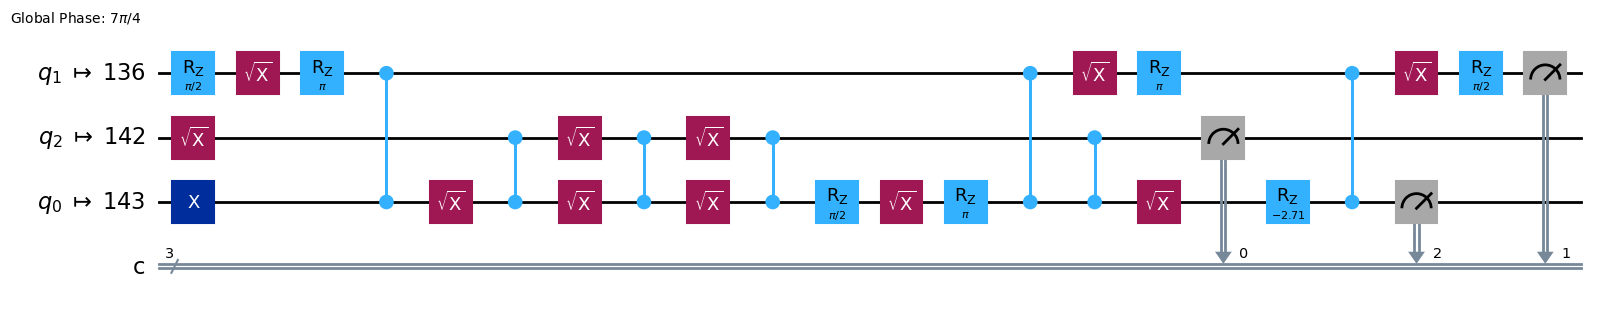

In [10]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [11]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "011" and state != "111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.0416015625
Errors for each run: [0.037109375, 0.0341796875, 0.0380859375, 0.0390625, 0.0400390625, 0.0400390625, 0.046875, 0.03515625, 0.0400390625, 0.0498046875, 0.05078125, 0.0458984375, 0.0498046875, 0.03515625, 0.0341796875, 0.0419921875, 0.048828125, 0.0302734375, 0.046875, 0.041015625, 0.0478515625, 0.0361328125, 0.0439453125, 0.03515625, 0.029296875, 0.0341796875, 0.044921875, 0.0322265625, 0.056640625, 0.03515625, 0.0458984375, 0.0341796875, 0.04296875, 0.0400390625, 0.0390625, 0.041015625, 0.037109375, 0.0390625, 0.05078125, 0.0458984375, 0.04296875, 0.046875, 0.04296875, 0.04296875, 0.0458984375, 0.044921875, 0.05078125, 0.0458984375, 0.044921875, 0.03515625]


In [1]:
import numpy as np
errors = [0.037109375, 0.0341796875, 0.0380859375, 0.0390625, 0.0400390625, 0.0400390625, 0.046875, 0.03515625, 0.0400390625, 0.0498046875, 0.05078125, 0.0458984375, 0.0498046875, 0.03515625, 0.0341796875, 0.0419921875, 0.048828125, 0.0302734375, 0.046875, 0.041015625, 0.0478515625, 0.0361328125, 0.0439453125, 0.03515625, 0.029296875, 0.0341796875, 0.044921875, 0.0322265625, 0.056640625, 0.03515625, 0.0458984375, 0.0341796875, 0.04296875, 0.0400390625, 0.0390625, 0.041015625, 0.037109375, 0.0390625, 0.05078125, 0.0458984375, 0.04296875, 0.046875, 0.04296875, 0.04296875, 0.0458984375, 0.044921875, 0.05078125, 0.0458984375, 0.044921875, 0.03515625]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.0416015625
Standard deviation of errors over 50 runs: 0.006057836882527665
0.0416 ± 0.0017 (95% CI)


In [12]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_kingston 156 0
ibm_marrakesh 156 0


In [13]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [14]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7aeen8eecps73d9dqng
Job ID: d7aeengeecps73d9dqog
Job ID: d7aeenqk86tc73a1gq0g
Job ID: d7aeeo2k86tc73a1gq10
Job ID: d7aeeoak86tc73a1gq20
Job ID: d7aeeoak86tc73a1gq30
Job ID: d7aeeoik86tc73a1gq4g
Job ID: d7aeeopq1efs73d401dg
Job ID: d7aeep2k86tc73a1gq5g
Job ID: d7aeepak86tc73a1gq6g


In [15]:
job_ids = [
    "d7aeen8eecps73d9dqng",
    "d7aeengeecps73d9dqog",
    "d7aeenqk86tc73a1gq0g",
    "d7aeeo2k86tc73a1gq10",
    "d7aeeoak86tc73a1gq20",
    "d7aeeoak86tc73a1gq30",
    "d7aeeoik86tc73a1gq4g",
    "d7aeeopq1efs73d401dg",
    "d7aeep2k86tc73a1gq5g",
    "d7aeepak86tc73a1gq6g",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "011" and state != "111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7aeen8eecps73d9dqng: error = 0.1113
Job d7aeengeecps73d9dqog: error = 0.0957
Job d7aeenqk86tc73a1gq0g: error = 0.1143
Job d7aeeo2k86tc73a1gq10: error = 0.1045
Job d7aeeoak86tc73a1gq20: error = 0.1084
Job d7aeeoak86tc73a1gq30: error = 0.1074
Job d7aeeoik86tc73a1gq4g: error = 0.1016
Job d7aeeopq1efs73d401dg: error = 0.0986
Job d7aeep2k86tc73a1gq5g: error = 0.1338
Job d7aeepak86tc73a1gq6g: error = 0.1104

Average error over runs: 0.10859375


Running on: ibm_fez (156 qubits)


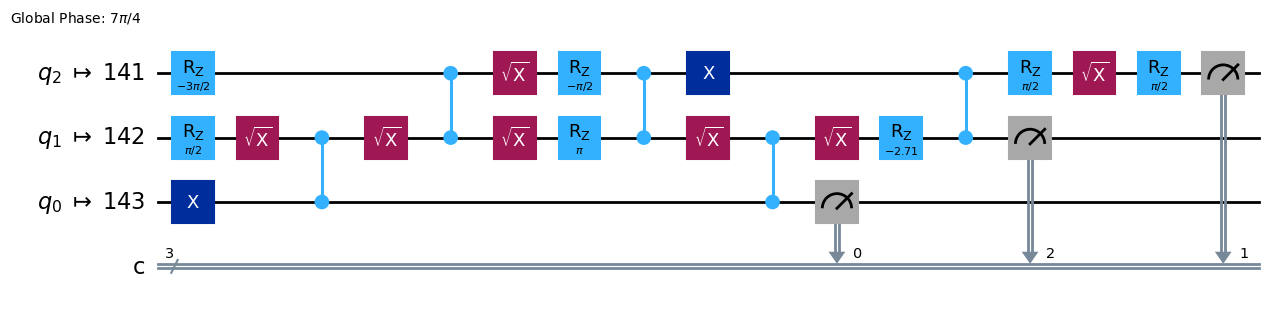

In [16]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [17]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7aeffjc6das739k43p0
Job ID: d7aeffqk86tc73a1gr2g
Job ID: d7aefg0eecps73d9drtg
Job ID: d7aefg9q1efs73d402d0
Job ID: d7aefghq1efs73d402e0
Job ID: d7aefgpq1efs73d402eg
Job ID: d7aefh3c6das739k43rg
Job ID: d7aefhak86tc73a1gr50
Job ID: d7aefhjc6das739k43tg
Job ID: d7aefhqk86tc73a1gr6g


In [19]:
job_ids = [
    "d7aeffjc6das739k43p0",
    "d7aeffqk86tc73a1gr2g",
    "d7aefg0eecps73d9drtg",
    "d7aefg9q1efs73d402d0",
    "d7aefghq1efs73d402e0",
    "d7aefgpq1efs73d402eg",
    "d7aefh3c6das739k43rg",
    "d7aefhak86tc73a1gr50",
    "d7aefhjc6das739k43tg",
    "d7aefhqk86tc73a1gr6g",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "011" and state != "111":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7aeffjc6das739k43p0: error = 0.0459
Job d7aeffqk86tc73a1gr2g: error = 0.0400
Job d7aefg0eecps73d9drtg: error = 0.0498
Job d7aefg9q1efs73d402d0: error = 0.0498
Job d7aefghq1efs73d402e0: error = 0.0508
Job d7aefgpq1efs73d402eg: error = 0.0518
Job d7aefh3c6das739k43rg: error = 0.0547
Job d7aefhak86tc73a1gr50: error = 0.0381
Job d7aefhjc6das739k43tg: error = 0.0479
Job d7aefhqk86tc73a1gr6g: error = 0.0449

Average error over runs: 0.04736328125
